In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import (
    auc, accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, mean_squared_error, r2_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('training_dataset.csv')
df_val = pd.read_csv('validation_set.csv')
pd.concat([df.head(10), df.tail(10)])

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
5,687725,34,manajer,cerai,Pendidikan Tinggi,no,yes,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Sumatera,0
6,884790,31,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,NTT,0
7,138535,29,asisten rumah tangga,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,Sumatera,0
8,300611,37,sosial media specialis,cerai,Pendidikan Tinggi,no,unknown,unknown,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera,0
9,423882,30,sosial media specialis,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,Sulawesi,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [4]:
pd.concat([df_val.head(10), df_val.tail(10)])

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,445420,35,penyedia jasa,menikah,SMA,no,yes,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,Jawa
1,585604,52,teknisi,lajang,Diploma,unknown,no,no,telephone,may,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,Papua
2,888824,37,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Bali
3,816820,51,pengangguran,menikah,Diploma,no,no,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera
4,542716,45,teknisi,cerai,SMA,no,yes,no,cellular,may,...,1,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,Sumatera
5,937852,43,pekerja kasar,menikah,Tidak Tamat SD,unknown,yes,no,telephone,may,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Kalimantan
6,434084,32,sosial media specialis,lajang,SMA,no,no,no,telephone,jun,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1,Papua
7,230861,35,pekerja kasar,menikah,SD,unknown,no,no,telephone,jun,...,7,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,Jawa
8,159684,61,pensiunan,cerai,Pendidikan Tinggi,no,yes,no,cellular,apr,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.384,5099.1,Kalimantan
9,274159,31,teknisi,menikah,Diploma,no,no,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,Sumatera


In [5]:
df.isnull().mean() * 100

customer_number                 0.0
usia                            0.0
pekerjaan                       0.0
status_perkawinan               0.0
pendidikan                      0.0
gagal_bayar_sebelumnya          0.0
pinjaman_rumah                  0.0
pinjaman_pribadi                0.0
jenis_kontak                    0.0
bulan_kontak_terakhir           0.0
hari_kontak_terakhir            0.0
jumlah_kontak_kampanye_ini      0.0
hari_sejak_kontak_sebelumnya    0.0
jumlah_kontak_sebelumnya        0.0
hasil_kampanye_sebelumnya       0.0
tingkat_variasi_pekerjaan       0.0
indeks_harga_konsumen           0.0
indeks_kepercayaan_konsumen     0.0
suku_bunga_euribor_3bln         0.0
jumlah_pekerja                  0.0
pulau                           0.0
berlangganan_deposito           0.0
dtype: float64

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop('customer_number',axis=1)

In [8]:
for col in df.columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 30)

Unique values in 'usia':
[63 43 29 40 34 31 37 30 54 32 39 33 48 36 47 50 45 38 44 28 25 42 57 26
 24 51 53 56 27 49 46 52 35 23 55 58 41 60 61 88 67 20 62 22 59 66 72 64
 78 70 69 75 19 18 92 76 83 21 82 71 17 77 81 68 73 79 80 65 86 74 85 84
 91 94 89 95 87 98]
------------------------------
Unique values in 'pekerjaan':
['sosial media specialis' 'teknisi' 'pekerja kasar' 'manajer'
 'asisten rumah tangga' 'mahasiswa' 'penyedia jasa' 'pemilik bisnis'
 'entrepreneur' 'pengangguran' 'pensiunan' 'unknown']
------------------------------
Unique values in 'status_perkawinan':
['menikah' 'lajang' 'cerai' 'unknown']
------------------------------
Unique values in 'pendidikan':
['Pendidikan Tinggi' 'SMA' 'Tidak Tamat SD' 'SMP' 'Diploma' 'SD' 'unknown'
 'TIDAK SEKOLAH']
------------------------------
Unique values in 'gagal_bayar_sebelumnya':
['no' 'unknown' 'yes']
------------------------------
Unique values in 'pinjaman_rumah':
['yes' 'no' 'unknown']
------------------------------
Unique val

In [9]:
for col in df.columns:
    print(f"Unique values in '{col}':")
    unique_counts = df[col].value_counts()
    for value, count in unique_counts.items():
        print(f"{value}= {count}")
    print("-" * 30)

Unique values in 'usia':
32= 1050
31= 1043
36= 1026
33= 1005
35= 983
30= 960
34= 958
37= 820
29= 803
38= 784
39= 782
41= 750
40= 628
42= 627
45= 608
44= 570
28= 566
43= 563
46= 554
48= 549
47= 516
50= 498
27= 475
49= 458
53= 430
51= 423
52= 421
56= 394
26= 384
54= 381
55= 361
57= 348
25= 337
58= 314
24= 246
59= 234
60= 178
23= 136
22= 79
21= 65
61= 41
64= 40
66= 38
20= 36
62= 33
63= 31
19= 30
71= 27
72= 23
65= 23
74= 23
68= 22
69= 22
70= 22
76= 21
67= 19
18= 17
73= 16
78= 15
75= 14
82= 12
77= 12
80= 12
85= 10
88= 9
83= 9
79= 7
81= 6
84= 5
86= 4
17= 3
92= 1
91= 1
94= 1
89= 1
95= 1
87= 1
98= 1
------------------------------
Unique values in 'pekerjaan':
sosial media specialis= 5755
pekerja kasar= 5191
teknisi= 3709
penyedia jasa= 2195
manajer= 1653
pensiunan= 968
entrepreneur= 815
pemilik bisnis= 784
asisten rumah tangga= 578
pengangguran= 561
mahasiswa= 514
unknown= 193
------------------------------
Unique values in 'status_perkawinan':
menikah= 13858
lajang= 6445
cerai= 2566
unknown= 

In [10]:
def count_subscription_based_on_unknown(df, subscription_col='berlangganan_deposito'):
    for col in df.columns:
        if col == subscription_col:
            continue
        
        unknown_rows = df[df[col] == 'unknown']
        if unknown_rows.empty:
            continue  # Lewati kolom jika tidak ada nilai unknown
        
        unknown_subscription_counts = unknown_rows[subscription_col].value_counts()
        
        print(col)
        for val in [0, 1]:
            count_val = unknown_subscription_counts.get(val, 0)
            print(f"  {val} = {count_val}")
            
        print()
# Panggil fungsi
count_subscription_based_on_unknown(df, 'berlangganan_deposito')

pekerjaan
  0 = 172
  1 = 21

status_perkawinan
  0 = 39
  1 = 8

pendidikan
  0 = 848
  1 = 144

gagal_bayar_sebelumnya
  0 = 4497
  1 = 248

pinjaman_rumah
  0 = 506
  1 = 73

pinjaman_pribadi
  0 = 506
  1 = 73



In [11]:
jumlah_unknown = (df == 'unknown').sum(axis=1).value_counts().sort_index()
print(jumlah_unknown)

0    16948
1     4995
2      789
3      175
4        8
5        1
Name: count, dtype: int64


In [12]:
df_numerik = df.select_dtypes(include='number')
df_kategorik = df.select_dtypes(include=['object', 'category'])

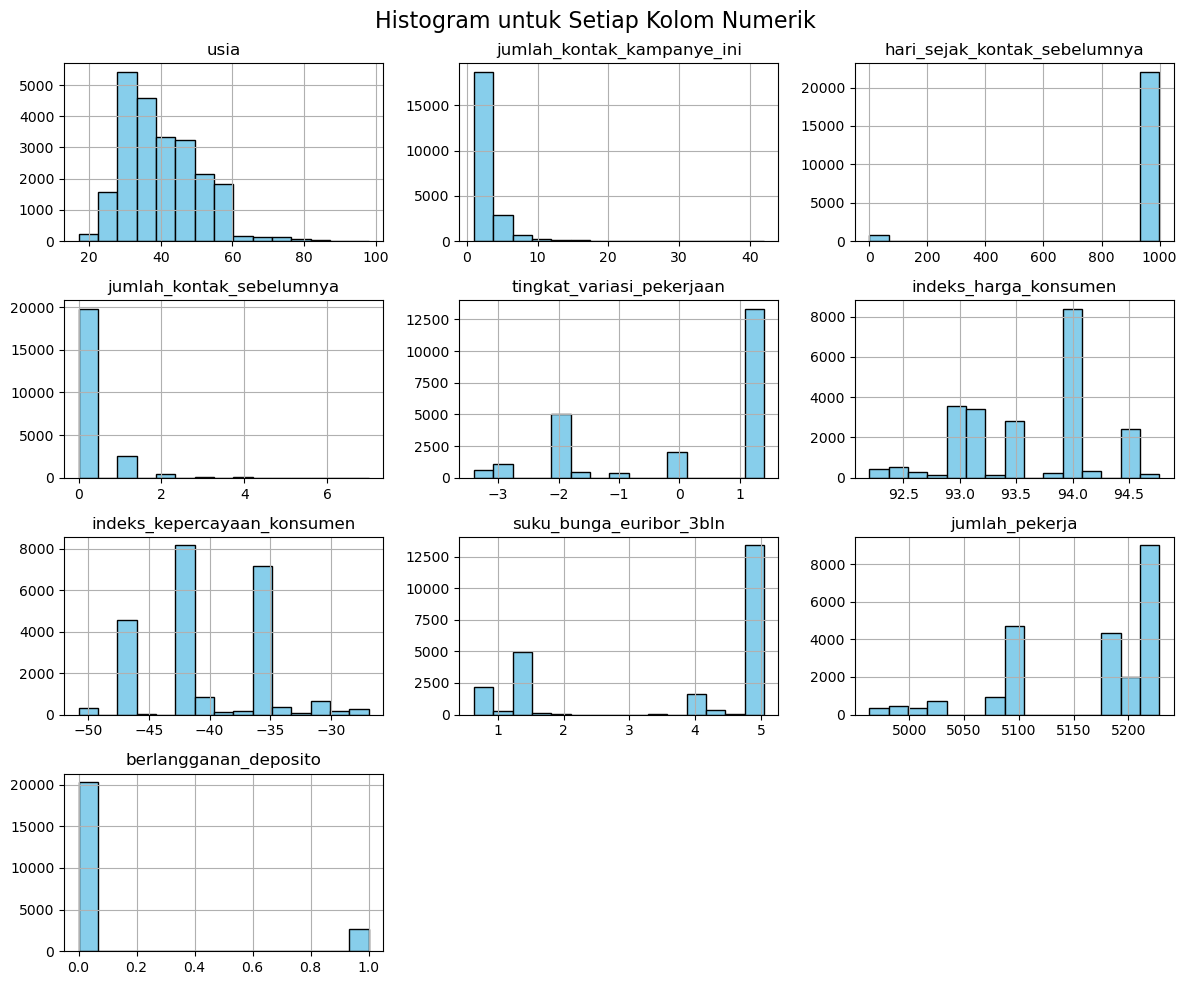

In [13]:
df_numerik.hist(figsize=(12, 10), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Histogram untuk Setiap Kolom Numerik', size=16)
plt.tight_layout()
plt.show()

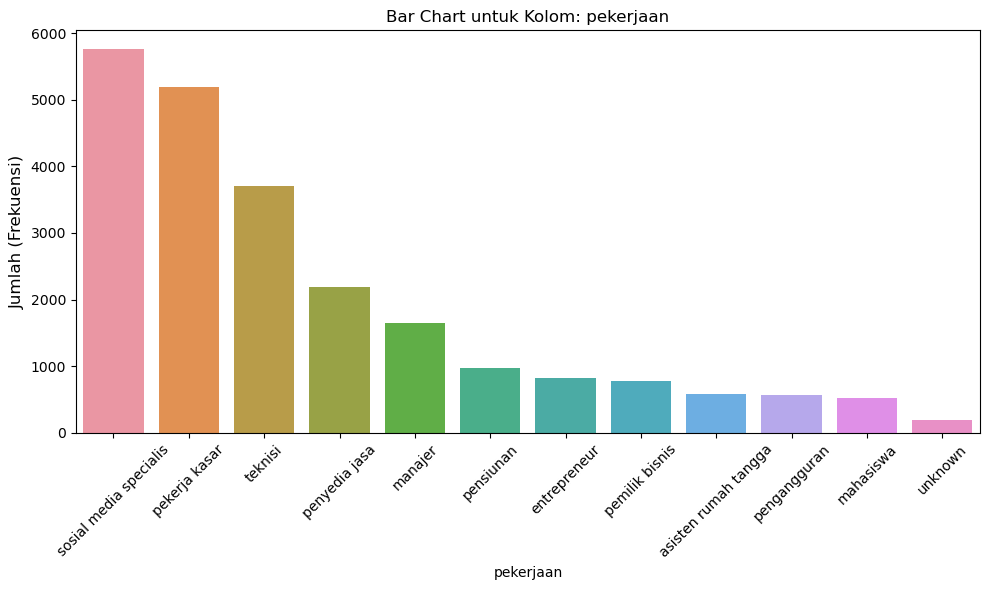

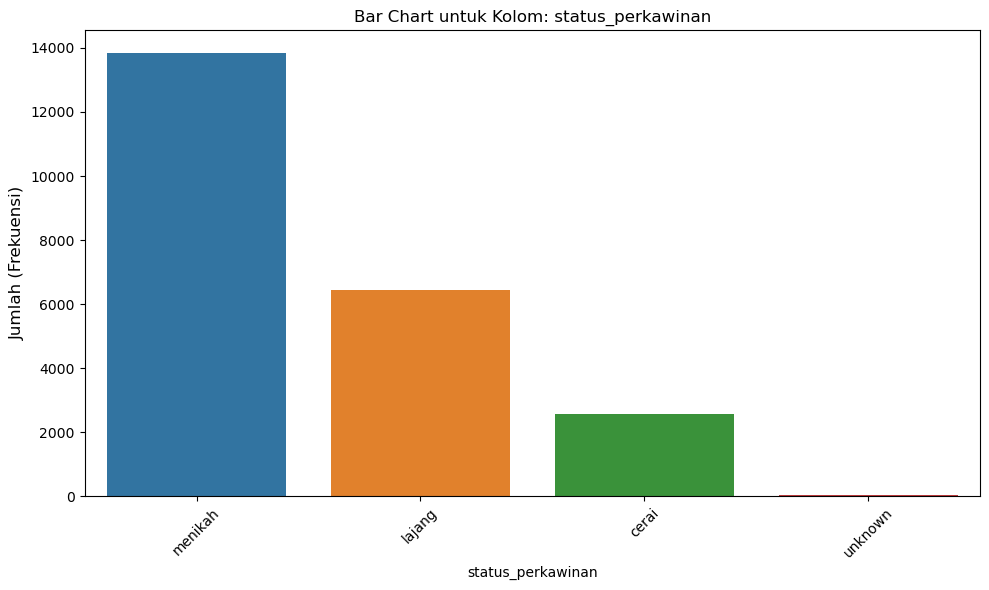

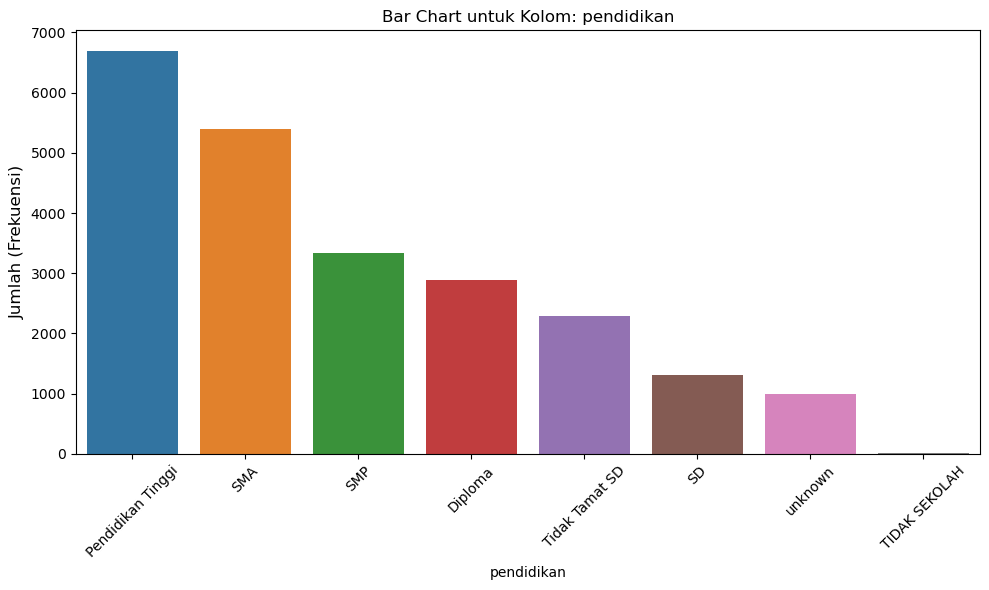

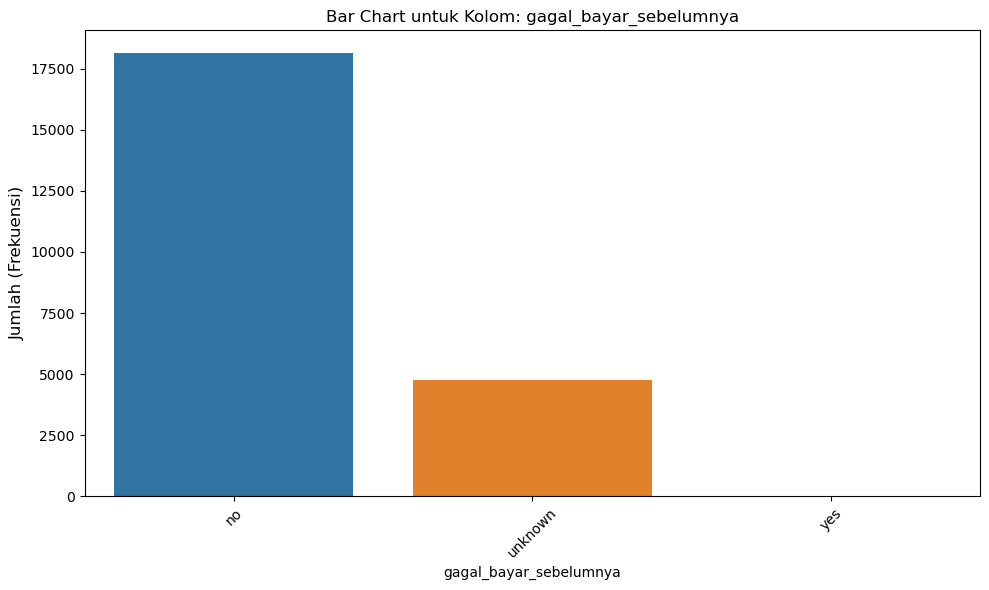

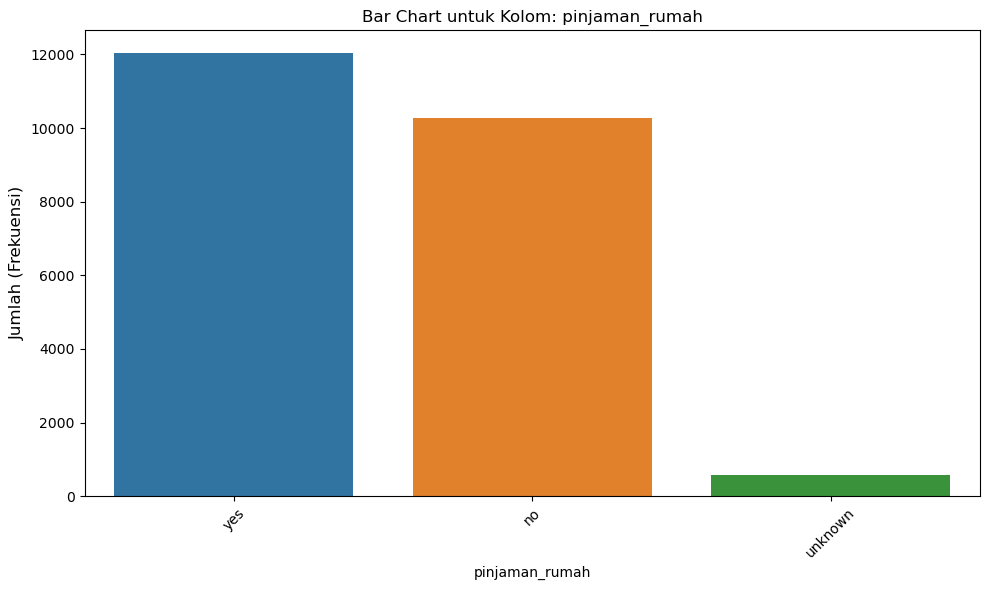

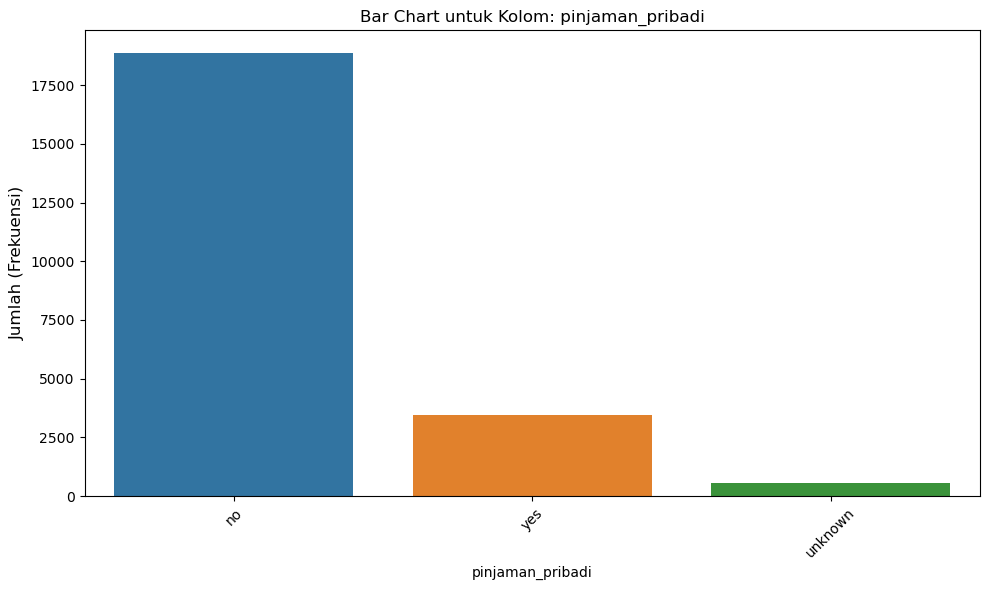

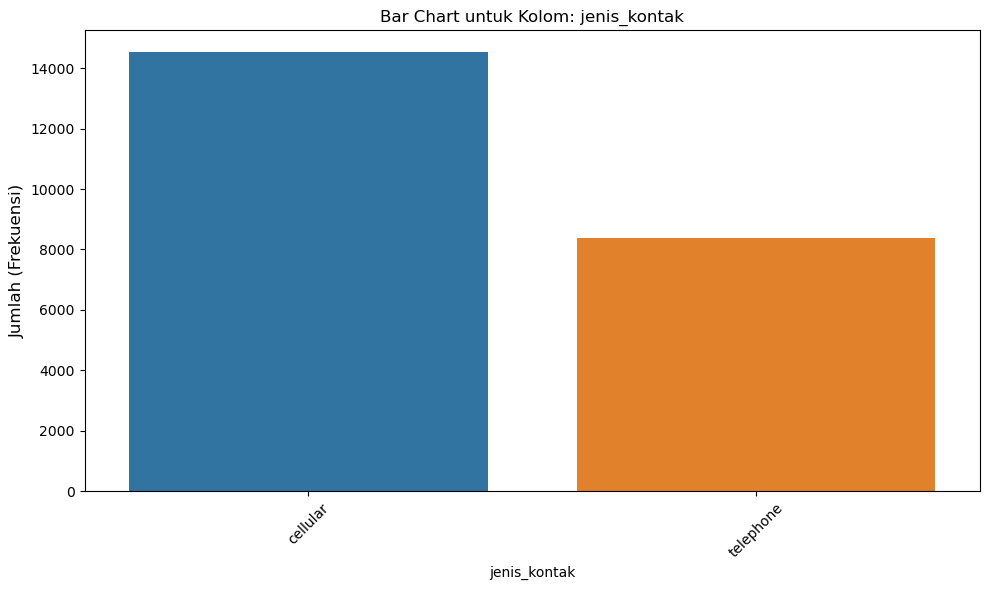

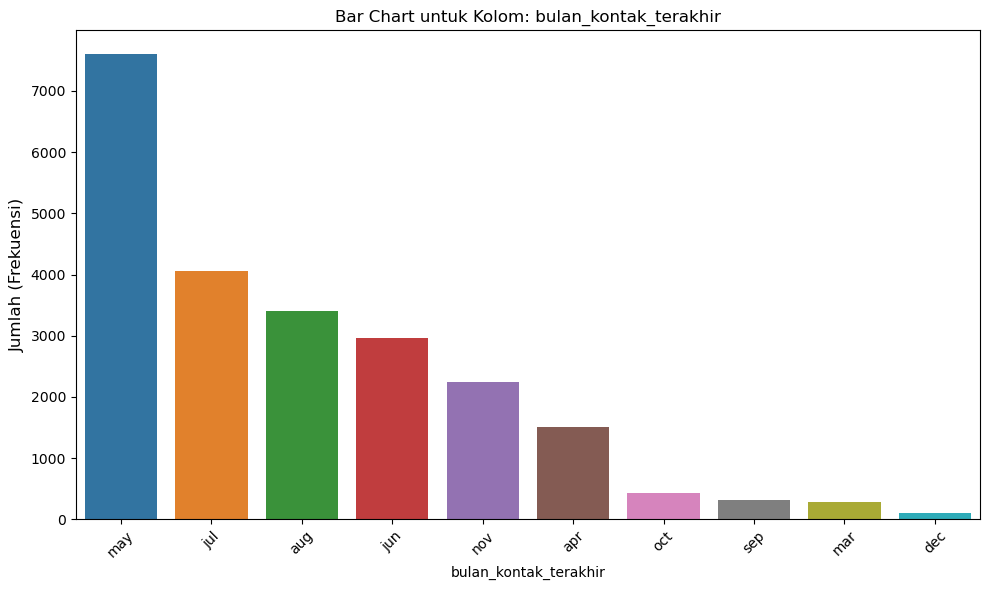

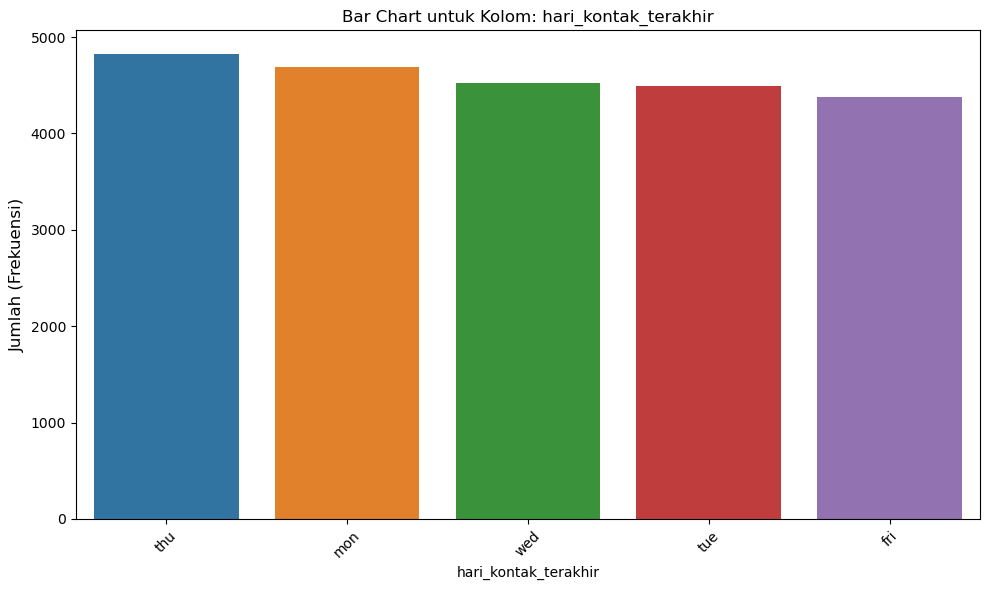

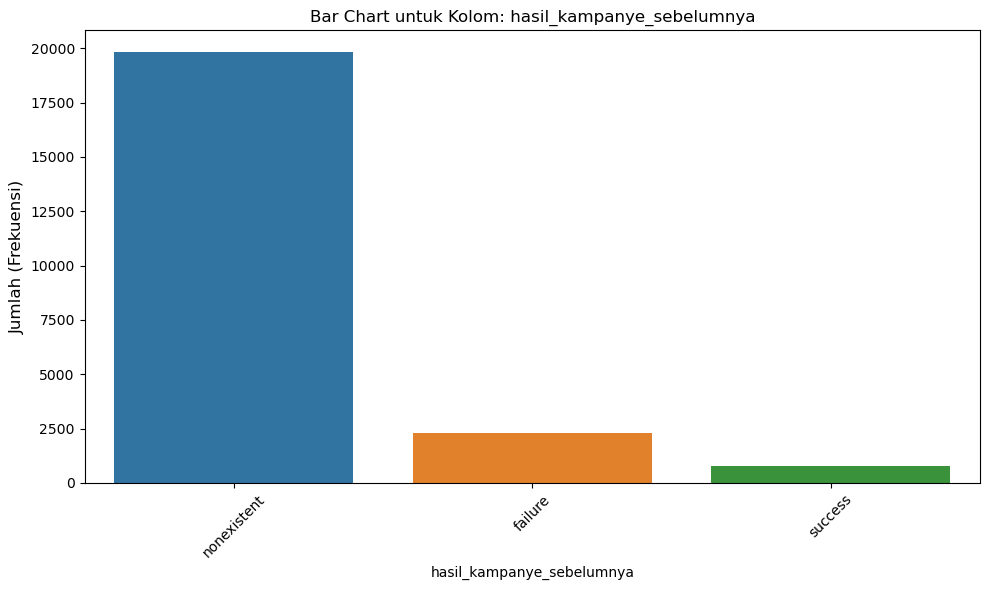

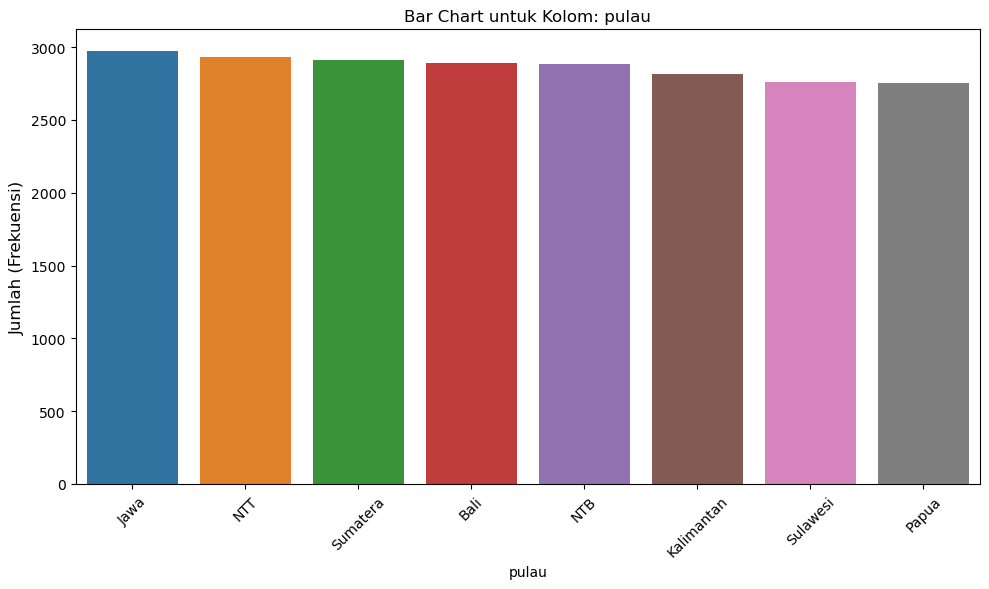

In [14]:
for column in df_kategorik.columns:
    plt.figure(figsize=(10, 6)) # Membuat figure baru untuk setiap plot
    counts = df_kategorik[column].value_counts()
    sns.barplot(x=counts.index, y=counts.values)
    
    plt.title(f'Bar Chart untuk Kolom: {column}', size=12)
    plt.xlabel(column, size=10)
    plt.ylabel('Jumlah (Frekuensi)', size=12)
    plt.xticks(rotation=45) # Rotasi label x agar mudah dibaca jika panjang
    plt.tight_layout()
    plt.show()


## Pre - Processing

In [56]:
df1 = df.copy()
df2 = df.copy()

### Data 2 (drop baris agar ordinal)

In [57]:
#df2['pernah_dihubungi'] = (df2['hari_sejak_kontak_sebelumnya'] != 999).astype(int)
#df2['pernah_dihubungi'] = np.where(df2['hari_sejak_kontak_sebelumnya'] == 999, 'No', 'Yes')
df2['hari_sejak_kontak_sebelumnya'] = df2['hari_sejak_kontak_sebelumnya'].replace(999, -1)
#df2 = df2.drop('hari_sejak_kontak_sebelumnya',axis=1)

In [17]:
#df2 = df2[df2['pendidikan'] != 'unknown']

In [58]:
df2['total_kontak'] = df2['jumlah_kontak_kampanye_ini'] + df2['jumlah_kontak_sebelumnya']

# Drop kedua kolom aslinya
df2.drop(['jumlah_kontak_kampanye_ini', 'jumlah_kontak_sebelumnya'], axis=1, inplace=True)

In [18]:
from scipy.stats import chi2_contingency, f_oneway, mannwhitneyu

# Target variable
target = 'berlangganan_deposito'

# Pisahkan kolom
categorical_features = [col for col in df2.columns if df2[col].dtype == 'object' and col != target]
numeric_features = [col for col in df2.columns if df2[col].dtype != 'object' and col != target]

# ======================
# Uji Chi-Square (Kategorik)
# ======================
print("=== Chi-Square Test (Categorical Features) ===")
for col in categorical_features:
    table = pd.crosstab(df2[col], df2[target])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")

# ======================
# ANOVA F-Test (Numerik)
# ======================
print("\n=== ANOVA F-Test (Numerical Features) ===")
for col in numeric_features:
    groups = [df2[df2[target]==val][col] for val in df2[target].unique()]
    f_stat, p = f_oneway(*groups)
    print(f"{col}: p-value = {p:.4f}")


=== Chi-Square Test (Categorical Features) ===
pekerjaan: p-value = 0.0000
status_perkawinan: p-value = 0.0000
pendidikan: p-value = 0.0000
gagal_bayar_sebelumnya: p-value = 0.0000
pinjaman_rumah: p-value = 0.2796
pinjaman_pribadi: p-value = 0.6309
jenis_kontak: p-value = 0.0000
bulan_kontak_terakhir: p-value = 0.0000
hari_kontak_terakhir: p-value = 0.0139
hasil_kampanye_sebelumnya: p-value = 0.0000
pulau: p-value = 0.4916

=== ANOVA F-Test (Numerical Features) ===
usia: p-value = 0.0000
jumlah_kontak_kampanye_ini: p-value = 0.0000
hari_sejak_kontak_sebelumnya: p-value = 0.0000
jumlah_kontak_sebelumnya: p-value = 0.0000
tingkat_variasi_pekerjaan: p-value = 0.0000
indeks_harga_konsumen: p-value = 0.0000
indeks_kepercayaan_konsumen: p-value = 0.0000
suku_bunga_euribor_3bln: p-value = 0.0000
jumlah_pekerja: p-value = 0.0000


In [23]:
from scipy.stats import zscore, kstest

target = 'berlangganan_deposito'

# Ambil kolom numerik saja
numeric_features = [col for col in df2.columns if df2[col].dtype != 'object' and col != target and col != 'pernah_dihubungi']

print("=== Kolmogorov-Smirnov Normality Test ===")
for col in numeric_features:
    # Standarisasi data jadi z-score
    z_scores = zscore(df[col].dropna())
    stat, p = kstest(z_scores, 'norm')
    print(f"{col}: p-value = {p:.4f}")


=== Kolmogorov-Smirnov Normality Test ===
usia: p-value = 0.0000
jumlah_kontak_kampanye_ini: p-value = 0.0000
hari_sejak_kontak_sebelumnya: p-value = 0.0000
jumlah_kontak_sebelumnya: p-value = 0.0000
tingkat_variasi_pekerjaan: p-value = 0.0000
indeks_harga_konsumen: p-value = 0.0000
indeks_kepercayaan_konsumen: p-value = 0.0000
suku_bunga_euribor_3bln: p-value = 0.0000
jumlah_pekerja: p-value = 0.0000


In [24]:
from scipy.stats import kstest, zscore

target = 'berlangganan_deposito'

# Ambil kolom numerik saja
numeric_features = [col for col in df2.columns if df2[col].dtype != 'object' and col != target]

print("=== Kolmogorov-Smirnov Normality Test ===")
for col in numeric_features:
    # Standarisasi data jadi z-score
    z_scores = zscore(df[col].dropna())
    stat, p = kstest(z_scores, 'norm')
    print(f"{col}: p-value = {p:.4f}")

=== Kolmogorov-Smirnov Normality Test ===
usia: p-value = 0.0000
jumlah_kontak_kampanye_ini: p-value = 0.0000
hari_sejak_kontak_sebelumnya: p-value = 0.0000
jumlah_kontak_sebelumnya: p-value = 0.0000
tingkat_variasi_pekerjaan: p-value = 0.0000
indeks_harga_konsumen: p-value = 0.0000
indeks_kepercayaan_konsumen: p-value = 0.0000
suku_bunga_euribor_3bln: p-value = 0.0000
jumlah_pekerja: p-value = 0.0000


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load dataset numerik
X_num = df2[numeric_features]

# Tambahkan konstanta untuk intercept di VIF
X_num_const = add_constant(X_num)

print("\n=== Variance Inflation Factor (VIF) ===")
vif_data = pd.DataFrame()
vif_data['Feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num_const.values, i+1) for i in range(len(X_num.columns))]

print(vif_data)



=== Variance Inflation Factor (VIF) ===
                        Feature        VIF
0                          usia   1.020186
1    jumlah_kontak_kampanye_ini   1.030556
2  hari_sejak_kontak_sebelumnya   1.408846
3      jumlah_kontak_sebelumnya   1.618349
4     tingkat_variasi_pekerjaan  33.510073
5         indeks_harga_konsumen   6.421837
6   indeks_kepercayaan_konsumen   2.642388
7       suku_bunga_euribor_3bln  65.015946
8                jumlah_pekerja  31.617763


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# List kolom yang mau dikecualikan dari VIF
exclude_cols = ['suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan']

# Ambil variabel numerik yang tidak termasuk kolom yang dikecualikan
X_num = df2[[col for col in numeric_features if col not in exclude_cols]]

# Tambahkan konstanta untuk intercept di VIF
X_num_const = add_constant(X_num)

# Hitung VIF
print("\n=== Variance Inflation Factor (VIF) ===")
vif_data = pd.DataFrame()
vif_data['Feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num_const.values, i+1) for i in range(len(X_num.columns))]

print(vif_data)


=== Variance Inflation Factor (VIF) ===
                        Feature       VIF
0                          usia  1.019534
1    jumlah_kontak_kampanye_ini  1.024373
2  hari_sejak_kontak_sebelumnya  1.406608
3      jumlah_kontak_sebelumnya  1.616591
4         indeks_harga_konsumen  1.408585
5   indeks_kepercayaan_konsumen  1.044574
6                jumlah_pekerja  1.820415


# TRAINING

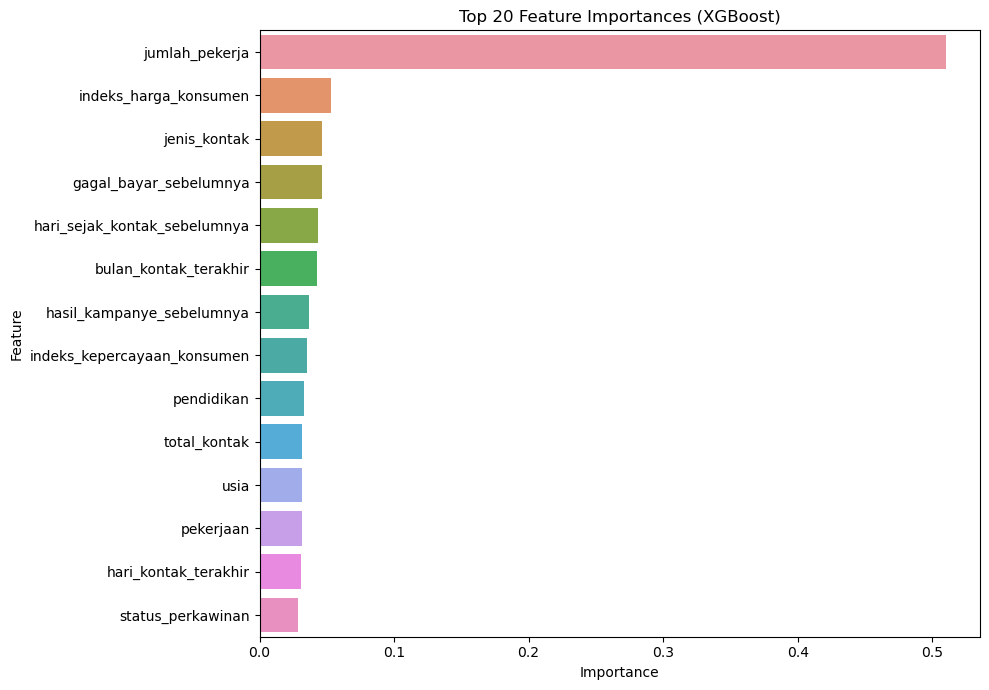

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler  # Import RobustScaler
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fitur dan target
X = df2.drop(columns=['berlangganan_deposito', 'pinjaman_pribadi', 'pinjaman_rumah', 
                      'pulau', 'suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan'])
y = df2['berlangganan_deposito']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kolom
numeric_features = ['usia',
                    'total_kontak', 'hari_sejak_kontak_sebelumnya',
                    'indeks_harga_konsumen',
                    'indeks_kepercayaan_konsumen', 'jumlah_pekerja']

categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col != 'pendidikan']
ordinal_feature = ['pendidikan']
pendidikan_order = ['unknown', 'TIDAK SEKOLAH', 'Tidak Tamat SD', 'SD', 'SMP', 'SMA', 'Diploma', 'Pendidikan Tinggi']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('ord', OrdinalEncoder(categories=[pendidikan_order]), ordinal_feature)
    ]
)

# Hitung scale_pos_weight
neg, pos = y_train.value_counts()
scale_weight = neg / pos

# XGB untuk seleksi fitur
xgb_selector = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_weight
)

pipeline_fs = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selector', SelectFromModel(estimator=xgb_selector, threshold='median'))
])

pipeline_fs.fit(X_train, y_train)

# Fitur hasil seleksi
selector = pipeline_fs.named_steps['feature_selector']
mask = selector.get_support()

# Nama fitur
preprocessor_fit = pipeline_fs.named_steps['preprocessor']
feature_names_num = numeric_features
feature_names_cat = preprocessor_fit.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names_ord = ordinal_feature
all_features = np.concatenate([feature_names_num, feature_names_cat, feature_names_ord])

# Importance
xgb_selector.fit(preprocessor_fit.transform(X_train), y_train)
importances = xgb_selector.feature_importances_

# DataFrame hasil importance
feature_importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 7))
sns.barplot(y='Feature', x='Importance', data=feature_importances.head(47))
plt.title('Top 20 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import optuna

# Final pipeline (tanpa SMOTE), nanti param-nya diisi hasil Optuna
def create_pipeline(params):
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42,
        **params
    )
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

# Objective function buat Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.00, 0.1),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.5),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "n_jobs": -1
    }
    pipeline = create_pipeline(params)

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_val_proba)
        scores.append(score)

    return np.mean(scores)

# Optuna tuning
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=35, show_progress_bar=True)

# Print hasil tuning
print(f"\nBest Parameters: {study.best_params}")
print(f"Best CV ROC AUC : {study.best_value:.4f}")

# Build final pipeline pakai best_params
final_pipeline = create_pipeline(study.best_params)

# Fit ke data train
final_pipeline.fit(X_train, y_train)

# Assign best_model ke final_pipeline
best_model = final_pipeline

# Evaluasi (TETAP sesuai format kamu)
y_train_pred = best_model.predict(X_train)
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Skor
print(f"\nTrain Accuracy  : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Train ROC AUC   : {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test Accuracy   : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test ROC AUC    : {roc_auc_score(y_test, y_test_proba):.4f}")

# Classification report
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

[I 2025-06-04 23:27:48,469] A new study created in memory with name: no-name-fff25d6a-7919-41e3-87dd-7a91fbd756f9


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2025-06-04 23:27:54,327] Trial 0 finished with value: 0.7804775619678912 and parameters: {'n_estimators': 221, 'learning_rate': 0.09767590322077012, 'max_depth': 12, 'min_child_weight': 10, 'subsample': 0.702782235412415, 'colsample_bytree': 0.33553897677576466, 'gamma': 1.595744653550066, 'reg_alpha': 1.9455681200277575, 'reg_lambda': 4.647395829807356}. Best is trial 0 with value: 0.7804775619678912.
[I 2025-06-04 23:27:57,542] Trial 1 finished with value: 0.7950782863277936 and parameters: {'n_estimators': 105, 'learning_rate': 0.048259322684228084, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.9999219963260642, 'colsample_bytree': 0.3984064988344386, 'gamma': 3.54861446344261, 'reg_alpha': 1.2011371044242236, 'reg_lambda': 0.9010720920276316}. Best is trial 1 with value: 0.7950782863277936.
[I 2025-06-04 23:28:03,225] Trial 2 finished with value: 0.7933643145982011 and parameters: {'n_estimators': 280, 'learning_rate': 0.028740087471412348, 'max_depth': 6, 'min_child_wei

[I 2025-06-04 23:29:29,091] Trial 21 finished with value: 0.7951913109619617 and parameters: {'n_estimators': 144, 'learning_rate': 0.030790909301437793, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.9091189435750963, 'colsample_bytree': 0.41719400243536303, 'gamma': 2.9826551697777726, 'reg_alpha': 4.5924628658902265, 'reg_lambda': 1.1075136103616474}. Best is trial 20 with value: 0.7952251004418622.
[I 2025-06-04 23:29:33,646] Trial 22 finished with value: 0.7952538912755209 and parameters: {'n_estimators': 148, 'learning_rate': 0.019958466933792468, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.8949988465144846, 'colsample_bytree': 0.43549828877913654, 'gamma': 2.971348193102884, 'reg_alpha': 4.736697849688166, 'reg_lambda': 0.5976053482815535}. Best is trial 22 with value: 0.7952538912755209.
[I 2025-06-04 23:29:38,154] Trial 23 finished with value: 0.7951111111708273 and parameters: {'n_estimators': 155, 'learning_rate': 0.019587264137824346, 'max_depth': 7, 'min_c

In [66]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from xgboost import XGBClassifier
import optuna
import numpy as np
import pandas as pd

# Fitur dan target
X = df2.drop(columns=['berlangganan_deposito', 'pinjaman_pribadi', 'pinjaman_rumah', 
                      'pulau', 'suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan'])
y = df2['berlangganan_deposito']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kolom
#numeric_features = ['usia',
#                    'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya',
#                    'jumlah_kontak_sebelumnya', 'indeks_harga_konsumen',
#                    'indeks_kepercayaan_konsumen', 'jumlah_pekerja']

numeric_features = ['usia',
                    'total_kontak', 'hari_sejak_kontak_sebelumnya',
                    'indeks_harga_konsumen',
                    'indeks_kepercayaan_konsumen', 'jumlah_pekerja']

categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col != 'pendidikan']
ordinal_feature = ['pendidikan']
pendidikan_order = ['unknown', 'TIDAK SEKOLAH', 'Tidak Tamat SD', 'SD', 'SMP', 'SMA', 'Diploma', 'Pendidikan Tinggi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('ord', OrdinalEncoder(categories=[pendidikan_order]), ordinal_feature)
    ]
)

# Hitung scale_pos_weight
neg, pos = y_train.value_counts()
scale_weight = neg / pos

# Fit preprocessor & XGB buat importance
X_train_processed = preprocessor.fit_transform(X_train)
xgb_selector = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=scale_weight)
xgb_selector.fit(X_train_processed, y_train)

# Ambil nama fitur hasil preprocessor
feature_names_num = numeric_features
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names_ord = ordinal_feature
all_features = np.concatenate([feature_names_num, feature_names_cat, feature_names_ord])

# Ambil 43 fitur teratas
importances = xgb_selector.feature_importances_
feature_importances = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
top_features = feature_importances.head(41)['Feature'].tolist()

# Dapetin index posisi 43 fitur tersebut di hasil preprocessor
selected_indices = [i for i, f in enumerate(all_features) if f in top_features]

# Final pipeline (pakai Optuna, cuma ambil fitur terpilih)
def create_pipeline(params):
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42,
        **params
    )
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selector', 'passthrough'),  # kita custom seleksi manual setelah transform
        ('classifier', model)
    ])
    return pipeline

# Objective function buat Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.00, 0.1),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.5),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "n_jobs": -1
    }
    pipeline = create_pipeline(params)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        X_tr_transformed = preprocessor.transform(X_tr)[:, selected_indices]
        X_val_transformed = preprocessor.transform(X_val_fold)[:, selected_indices]

        model = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=scale_weight,
            random_state=42,
            **params
        )
        model.fit(X_tr_transformed, y_tr)
        y_val_proba = model.predict_proba(X_val_transformed)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_proba)
        scores.append(score)

    return np.mean(scores)

# Optuna tuning
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=35, show_progress_bar=True)

# Build final model
best_params = study.best_params
print(f"\nBest Parameters: {best_params}")
print(f"Best CV ROC AUC : {study.best_value:.4f}")

# Final fit di full train
X_train_final = preprocessor.transform(X_train)[:, selected_indices]
X_test_final  = preprocessor.transform(X_test)[:, selected_indices]

final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_weight,
    random_state=42,
    **best_params
)
final_model.fit(X_train_final, y_train)
best_model = final_model

# Evaluasi
y_train_pred = final_model.predict(X_train_final)
y_train_proba = final_model.predict_proba(X_train_final)[:, 1]
y_test_pred = final_model.predict(X_test_final)
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

print(f"\nTrain Accuracy  : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Train ROC AUC   : {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test Accuracy   : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test ROC AUC    : {roc_auc_score(y_test, y_test_proba):.4f}")

print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

[I 2025-06-04 23:31:13,891] A new study created in memory with name: no-name-d9081b7f-d503-46b8-bba7-ecfc7c49aaef


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2025-06-04 23:31:19,227] Trial 0 finished with value: 0.7871008498933441 and parameters: {'n_estimators': 272, 'learning_rate': 0.08835544494290878, 'max_depth': 11, 'min_child_weight': 8, 'subsample': 0.8847137123055282, 'colsample_bytree': 0.42463471862567537, 'gamma': 2.095880068301153, 'reg_alpha': 4.008064277998558, 'reg_lambda': 4.466760284953481}. Best is trial 0 with value: 0.7871008498933441.
[I 2025-06-04 23:31:24,200] Trial 1 finished with value: 0.7924245474450361 and parameters: {'n_estimators': 173, 'learning_rate': 0.030146891111387988, 'max_depth': 9, 'min_child_weight': 7, 'subsample': 0.8353735729102941, 'colsample_bytree': 0.4395314182583465, 'gamma': 2.7282611925971034, 'reg_alpha': 1.2129224200335549, 'reg_lambda': 4.9747278278331235}. Best is trial 1 with value: 0.7924245474450361.
[I 2025-06-04 23:31:28,995] Trial 2 finished with value: 0.7940496742389924 and parameters: {'n_estimators': 256, 'learning_rate': 0.04458482437257656, 'max_depth': 11, 'min_child_we

[I 2025-06-04 23:32:55,792] Trial 20 finished with value: 0.7934355029228831 and parameters: {'n_estimators': 168, 'learning_rate': 0.03326980545255314, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.6137414226790862, 'colsample_bytree': 0.3571161897757669, 'gamma': 1.7920333446283676, 'reg_alpha': 0.7163746935352064, 'reg_lambda': 4.220802614877973}. Best is trial 11 with value: 0.7955467485047145.
[I 2025-06-04 23:33:01,865] Trial 21 finished with value: 0.7952687854859686 and parameters: {'n_estimators': 295, 'learning_rate': 0.01730017855469317, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.6892638567922666, 'colsample_bytree': 0.33200956689845273, 'gamma': 1.1465409785445333, 'reg_alpha': 0.6414497051900527, 'reg_lambda': 3.7532594769725365}. Best is trial 11 with value: 0.7955467485047145.
[I 2025-06-04 23:33:08,423] Trial 22 finished with value: 0.7956318109446514 and parameters: {'n_estimators': 286, 'learning_rate': 0.01823237386983326, 'max_depth': 6, 'min_chil

# VALIDATION

In [67]:
df_val['hari_sejak_kontak_sebelumnya'] = df_val['hari_sejak_kontak_sebelumnya'].replace(999, -1)

In [68]:
df_val['total_kontak'] = df_val['jumlah_kontak_kampanye_ini'] + df_val['jumlah_kontak_sebelumnya']

# Drop kedua kolom aslinya
df_val.drop(['jumlah_kontak_kampanye_ini', 'jumlah_kontak_sebelumnya'], axis=1, inplace=True)

In [71]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               5729 non-null   int64  
 1   usia                          5729 non-null   int64  
 2   pekerjaan                     5729 non-null   object 
 3   status_perkawinan             5729 non-null   object 
 4   pendidikan                    5729 non-null   object 
 5   gagal_bayar_sebelumnya        5729 non-null   object 
 6   pinjaman_rumah                5729 non-null   object 
 7   pinjaman_pribadi              5729 non-null   object 
 8   jenis_kontak                  5729 non-null   object 
 9   bulan_kontak_terakhir         5729 non-null   object 
 10  hari_kontak_terakhir          5729 non-null   object 
 11  hari_sejak_kontak_sebelumnya  5729 non-null   int64  
 12  hasil_kampanye_sebelumnya     5729 non-null   object 
 13  tin

In [73]:
X_val = df_val.drop(columns=['customer_number', 
                             'pinjaman_pribadi', 'pinjaman_rumah', 
                             'pulau', 'suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan'])
X_val_processed = preprocessor.transform(X_val)[:, selected_indices]

# Baru predict proba-nya
y_val_proba = final_model.predict_proba(X_val_processed)[:, 1]

# Buat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'customer_number': df_val['customer_number'],
    'berlangganan_deposito': y_val_proba
})

# Simpan ke CSV
hasil_prediksi.to_csv('SUBMIT_3.csv', index=False)

print("Prediksi probabilitas berhasil disimpan ke hasil_prediksi_validasi.csv")

Prediksi probabilitas berhasil disimpan ke hasil_prediksi_validasi.csv


In [74]:
hasil_prediksi

,customer_number,berlangganan_deposito
0,445420,0.343495
1,585604,0.242576
2,888824,0.213279
3,816820,0.208719
4,542716,0.386538
...,...,...
5724,782072,0.300095
5725,116371,0.246225
5726,773759,0.169226
5727,612330,0.208162
